# Fase 0: Introduzione

In questo Jupyter Notebook sarà possibile consultare la realizzazione del primo obiettivo del Project Work "Triage automatico dei ticket con Machine Learning". Gli obiettivi da raggiungere sono:
- *Pipeline ML*
    - Preprocessing: pulizia base del testo (minuscole, rimozione punteggiatura), tokenizzazione.
    - Modello classificazione categoria (Amministrazione/Tecnico/Commerciale).
    - Modello stima priorità (Bassa/Media/Alta).
    - Valutazione: train/test 80/20, accuracy e F1 macro; matrice di confusione.

Nello specifico, viene presentata un'analisi dei processi esplorazione, pulizia e modellazione predittiva applicati ai dataset creati in precedenza. Sarà possibile modificare il nome del dataset dalla prima cella di codice per testare le differenze.
- Fase 1: Lettura dei dati e EDA (Exploratory Data Analysis)
    - In questa fase iniziale si esegue il caricamento del dataset e una prima ispezione per verificarne la struttura. Viene analizzata la distribuzione delle categorie e della priorità grazie all'ausilio di diversi grafici. Inoltre, viene approfondita la struttura testuale calcolando la lunghezza delle parole all'interno del corpo dei ticket
- Fase 2: Preprocessing
    - Qui viene implementata una funzione di pulizia del testo basata sulle espressioni regolari per standardizzare la struttura dei record, rimuovendo in maniera particolare la punteggiatura e i caratteri speciali, preparando la base di dati alla successiva fase di vettorizzazione.
- Fase 3: Modello classificazione categoria
    - In questa fase vengono esplorate le varie strategie adottate per creare un modello di classificazione delle categorie dei vari ticket
- Fase 4: Modello classificazione priorità
    - In questa fase ci si concentra invece sulle varie strategie adottate per la stima della priorità dei vari ticket, testando l'efficacia dei modelli predittivi su classi che presentano distribuzioni differenti.
- Fase 5: Esportazione dei modelli
    Salvataggio definitivo dei modelli che hanno ottenuto la migliore prestazione per creazione della dashboard
- Fase 6: Valutazione generale dei vari modelli nei dataset analizzati e possibili miglioramenti 
    - Il notebook terminerà con un'analisi generale dei modelli sui 3 dataset presi come riferimento e una breve discussione di possibili miglioramenti della pipeline

In [ ]:
dataset = "Dataset/ticket_gemma4e2b.csv"

# Fase 1: Lettura dei dati e EDA (Exploratory Data Analysis)

In [ ]:
import pandas as pd
df = pd.read_csv(dataset)
df.sample(10)

,id,title,body,category,priority
374,TK-374,Richiesta di supporto per negoziazione contrat...,Ho bisogno di assistenza immediata per finaliz...,Commerciale,Media
207,TK-207,Assistenza immediata per errore configurazione...,Ho un'urgenza assoluta: il mio server non si a...,Tecnico,Alta
69,TK-69,Richiesta info (non urgente): Problemi con l'i...,Ho difficoltà a completare le procedure di ins...,Amministrazione,Media
365,TK-365,Chiarimento su negoziazione contratto commerci...,Ho un'urgenza assoluta: Sto riscontrando un bl...,Commerciale,Alta
380,TK-380,Chiarimento su gestione contratto commerciale,Vi scrivo per una questione non urgente: Ho bi...,Commerciale,Bassa
392,TK-392,Procedura per gestione spese amministrative,Non riesco a visualizzare correttamente i dati...,Amministrazione,Media
455,TK-455,Segnalazione minore su errore di connessione rete,Ho già provato a riavviare il router ma la con...,Tecnico,Media
178,TK-178,Richiesta urgente: Blocco gestione fatture,Situazione critica su Amministrazione. Non rie...,Amministrazione,Alta
421,TK-421,Assistenza immediata per blocco sistema contab...,Non si può andare avanti così! Ho appena prova...,Amministrazione,Alta
152,TK-152,Segnalazione errore su configurazione rete,Il router non si connette e il ping è impossib...,Tecnico,Media


In [ ]:
df['category'].value_counts(ascending=False)

category
Commerciale        178
Tecnico            163
Amministrazione    159
Name: count, dtype: int64

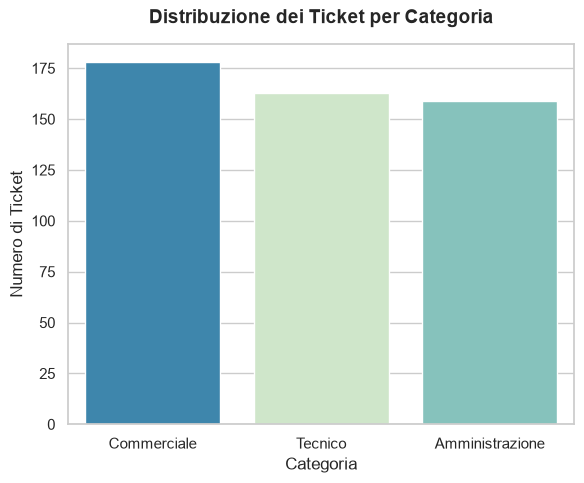

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

#GRAFICO 1: Numero di ticket per ogni categoria (in ordine decrescente)

#ordine delle categorie dal valore più alto al più basso
ordine_categorie = df['category'].value_counts().index

fig1, ax1 = plt.subplots(figsize=(6, 5))
sns.countplot(
    data=df, 
    x='category', 
    order=ordine_categorie, 
    hue='category', 
    palette='GnBu_r', 
    ax=ax1
)

#rimuovo la legenda automatica del parametro 'hue' che in questo caso è ridondante
if ax1.get_legend() is not None:
    ax1.get_legend().remove()

ax1.set_title('Distribuzione dei Ticket per Categoria', fontsize=14, pad=15, fontweight='bold')
ax1.set_xlabel('Categoria', fontsize=12)
ax1.set_ylabel('Numero di Ticket', fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
df.groupby('category')['priority'].value_counts(ascending=False)

category         priority
Amministrazione  Alta        56
                 Bassa       55
                 Media       48
Commerciale      Alta        60
                 Media       60
                 Bassa       58
Tecnico          Bassa       63
                 Media       51
                 Alta        49
Name: count, dtype: int64

In [ ]:
df['priority'].value_counts(ascending=False)

priority
Bassa    176
Alta     165
Media    159
Name: count, dtype: int64

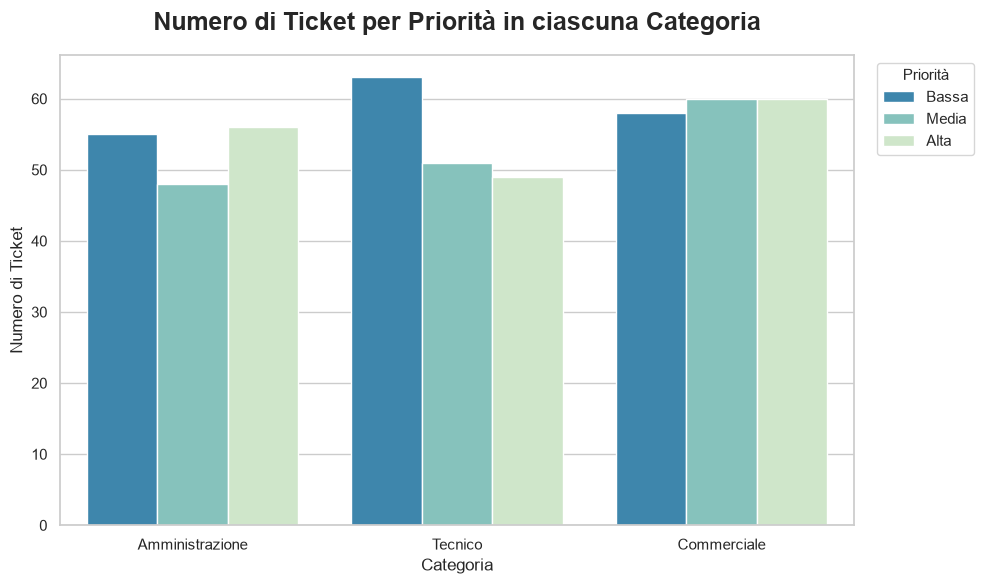

In [ ]:
fig2, ax2 = plt.subplots(figsize=(10, 6))

order = ['Amministrazione', 'Tecnico', 'Commerciale']
sns.countplot(
    data=df, 
    x='category',
    order = order, 
    hue='priority', 
    hue_order=['Bassa', 'Media', 'Alta'],
    palette='GnBu_r', 
    ax=ax2
)

#leggenda ed etichette varie
ax2.set_title('Numero di Ticket per Priorità in ciascuna Categoria', fontsize=18, pad=18, fontweight='bold')
ax2.set_xlabel('Categoria', fontsize=12)
ax2.set_ylabel('Numero di Ticket', fontsize=12)
ax2.legend(title='Priorità', title_fontsize='11', loc='upper left',bbox_to_anchor=(1.02,1))


plt.tight_layout()
plt.show()

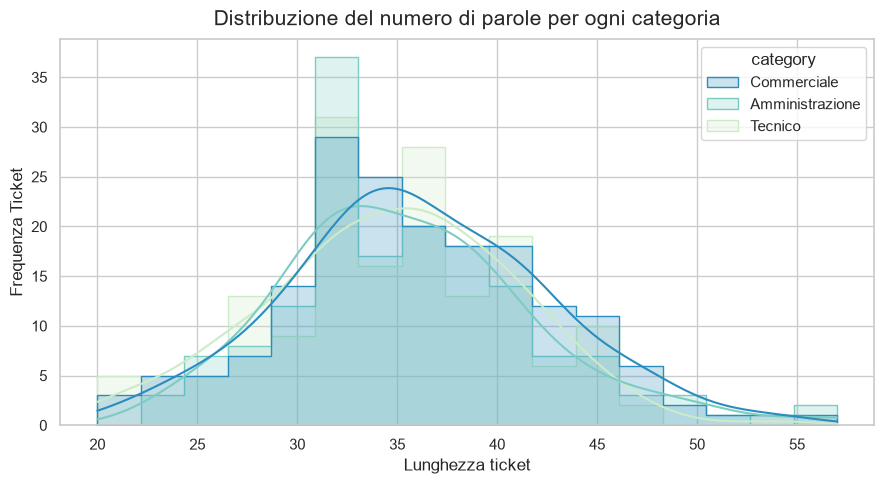

In [ ]:
df['ticket_completo'] = df['title'].fillna('') + " " + df['body'].fillna('')
df['word_count'] = df['ticket_completo'].apply(lambda x: len(x.split()))

#grafico della distribuzione della lunghezza
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df, x='word_count', hue='category', kde=True, element='step', palette='GnBu_r', ax=ax)

ax.set_title('Distribuzione del numero di parole per ogni categoria', fontsize=15, pad=10)
ax.set_xlabel('Lunghezza ticket')
ax.set_ylabel('Frequenza Ticket')

plt.tight_layout()
plt.show()

# Fase 2: Preprocessing

Preprocessing del testo, ovvero pulizia base del testo (rimozione elemeni nan, minuscole, punteggiatura).

In [ ]:
df = df.dropna(subset=['title','category', 'priority','body'])

La funzione *clean_text(text)* utilizza regex per rimuovere tutti gli elementi che non sono lettere o spazi. in più porta tutte le parole in miniscolo.

In [ ]:
import re
import pandas as pd

def clean_text(text):
    
    text = str(text).lower()
    
    #^\w\s significa "tutto ciò che NON è una lettera/numero (\w) o uno spazio (\s)"
    text = re.sub(r'[^\w\s]', '', text)
    
    #rimuove spazi in generale
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


Esempio di pulizia in un record estratto casualmente:

In [ ]:
test_record = df.sample(n=1)

print("--- RECORD REALE ESTRATTO ---")
print(test_record[['title','category', 'priority','body']])

print("\n--- RISULTATO DOPO LA PULIZIA ---")
clean_record = test_record[['title', 'category', 'priority','body']].map(clean_text)
print(clean_record)

--- RECORD REALE ESTRATTO ---
                                           title     category priority  \
192  Urgente: non va la fatturazione commerciale  Commerciale     Alta   

                                                  body  
192  Ho un problema con il sistema di fatturazione ...  

--- RISULTATO DOPO LA PULIZIA ---
                                          title     category priority  \
192  urgente non va la fatturazione commerciale  commerciale     alta   

                                                  body  
192  ho un problema con il sistema di fatturazione ...  


La necessità dell'implementazione della funzione *remove_key_word* è maturata a seguito di diverse fasi di testing fallimentari con i dataset realizzati da Gemma. Il suo scopo è quello di rimuovere le radici delle parole che svelano la categoria, ovvero togliere parole come commerciale, amministrazione, amministrativo, ecc, in modo da farle diventare irrilevanti dato che creavano problemi di Data Leakage. Questo fa in modo che:
- Non si induca il modello in overfitting, limitando la sua generalizzazione su dati che non appartengano al dataset
- Costringa gli algoritmi che sono stati utilizzati a focalizzarsi sul reale contesto semantico del ticket 

In [ ]:
import re

def remove_key_word(testo):
    testo = testo.lower()
    # Rimuoviamo le radici delle parole che svelano la categoria
    testo = re.sub(re.compile(r'\b(tecnic\w*|commercial\w*|amministrat\w*|fattur\w*)\b'), '', testo)
    return testo

# Applica la pulizia prima dello split
df['ticket_completo'] = (df['title'] + " " + df['body']).apply(remove_key_word)

Processo di tokenizzazione. Per farlo, viene aggiunta una nuova colonna chiamata 'token'

In [ ]:
df[['title', 'category', 'priority','body']]= df[['title', 'category', 'priority','body']].map(clean_text)

df['token'] = df['ticket_completo'].map(clean_text).str.split()
print(df['token'])

0      [avrei, bisogno, di, un, controllo, su, urgent...
1      [emergenza, problemi, con, lupload, delle, non...
2      [emergenza, blocco, impossibile, procedere, co...
3      [info, per, gestione, spese, ho, bisogno, di, ...
4      [bloccato, su, report, di, q3, non, riesco, ad...
                             ...                        
495    [assistenza, immediata, per, problema, conness...
496    [info, di, routine, per, troubleshooting, rete...
497    [richiesta, urgente, il, sistema, è, completam...
498    [urgente, non, va, la, ho, un, problema, sono,...
499    [curiosità, riguardo, a, configurazione, rete,...
Name: token, Length: 500, dtype: object


Altro EDA per analizzare le parole più frequenti nel dataset

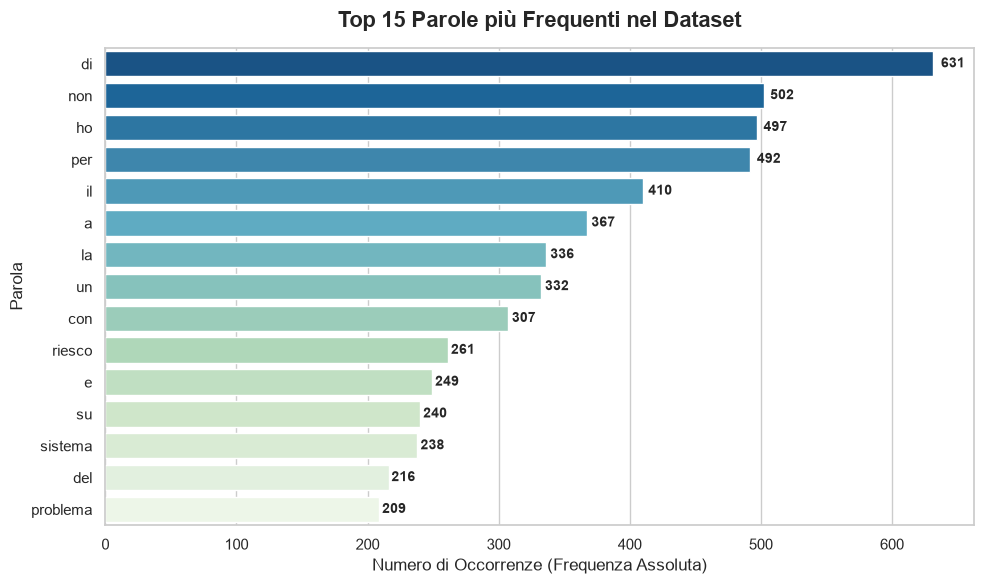

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_words = df['token'].explode().value_counts().head(15).reset_index()

top_words.columns = ['Parola', 'Frequenza']

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid") #sfondo pulito con griglia leggera

#grafico a barre orizzontali (barpot)
sns.barplot(
    x='Frequenza', 
    y='Parola', 
    data=top_words, 
    palette='GnBu_r', 
    hue='Parola',
    legend=False
)

#personalizza i testi e i titoli
plt.title('Top 15 Parole più Frequenti nel Dataset', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Numero di Occorrenze (Frequenza Assoluta)', fontsize=12)
plt.ylabel('Parola', fontsize=12)

#per mettere in risalto i valori numerici alla fine di ogni barra
for index, value in enumerate(top_words['Frequenza']):
    plt.text(value + (value * 0.01), index, f'{int(value)}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

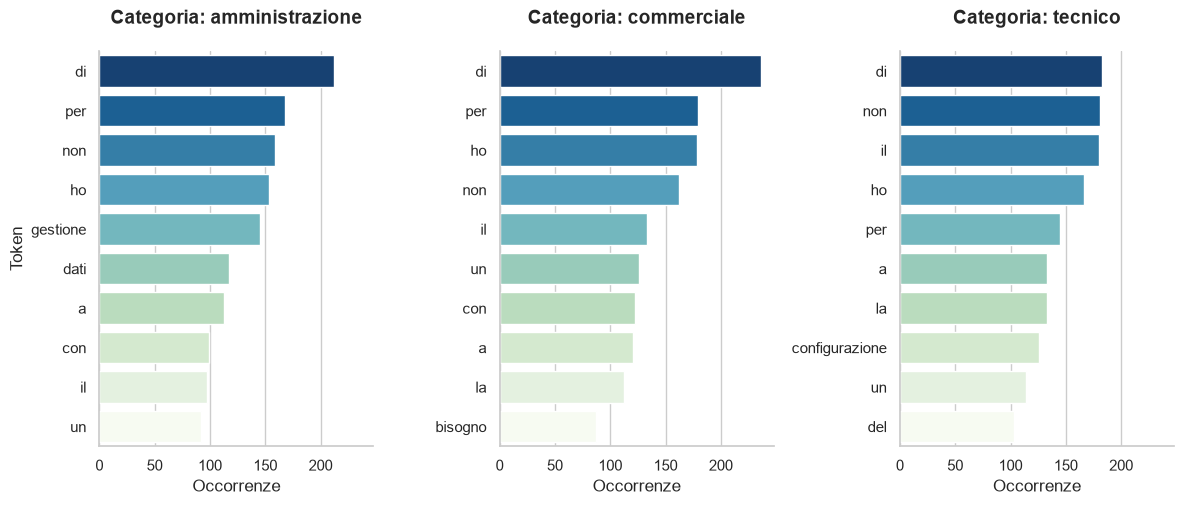

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
words_by_category = (df[['category', 'token']]
                     .explode('token')
                     .groupby(['category', 'token'])
                     .size()
                     .reset_index(name='Frequenza'))

#solo le top 10 parole per ogni singola categoria per non affollare il grafico
top_words_per_cat = (words_by_category
                     .sort_values(['category', 'Frequenza'], ascending=[True, False])
                     .groupby('category')
                     .head(10))

top_words_per_cat = top_words_per_cat.rename(columns={'token': 'Parola'})
top_words_per_cat['Word_Rank'] = top_words_per_cat.groupby('category').cumcount()
g = sns.catplot(
    data=top_words_per_cat, 
    kind="bar",
    x="Frequenza",  
    y="Parola",
    col="category",
    palette="GnBu_r",
    hue="Word_Rank",
    legend=False,
    sharey=False,
    height=5, 
    aspect=0.8
)

g.set_titles("Categoria: {col_name}", size=14, weight='bold',pad=20)
g.set_xlabels("Occorrenze", size=12)
g.set_ylabels("Token", size=12)


plt.show()

# Fase 3: Modello classificazione categoria:

Il problema da affrontare in questa fase è la creazione di codice per un modello che riesca a classificare la categoria di un ticket. 

A seguire è presente un analisi degli algoritmi utilizzati con una loro valutazione sul dataset.

### Algoritmo di classificazione LinearSVC.

Citando Wikipedia:
- [Inglese](https://en.wikipedia.org/wiki/Support_vector_machine)
- [Italiano](https://it.wikipedia.org/wiki/Macchine_a_vettori_di_supporto)

"Le macchine a vettori di supporto (SVM, dall'inglese support-vector machines o networks) sono dei modelli di apprendimento supervisionato associati ad algoritmi di apprendimento per la regressione e la classificazione."

All'interno di questi modelli supervisionati, LinearSVC (Linear Support Vector Classifier) è una variante specializzata esclusivamente per compiti di classificazione in cui il confine tra le diverse categorie può essere tracciato mediante una linea retta 

Per poter utilizzare questo algoritmo, è stata necessaria compiere un azione di vettorizzazione dei ticket. Ho sfruttato la libreria [*TfidfVectorizer*](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) che ho ritenuta ottima per il problema in questione grazie alla sua capacità di trasformare il testo in vettori numerici pesati, evidenziando le parole chiave più rilevanti di ogni ticket ed escludendo il "rumore" di fondo della lingua parlata.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

#definisco le Feature (X) e il Target (y) => non uso df['token'] perché TF-IDF effettua naturalmente una tokenizzazione
X = df['ticket_completo']
y = df['category']

#suddivisione in Train Set (80%) e Test Set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

#estrazione delle Feature con TF-IDF
vectorizer_categoria = TfidfVectorizer(
    sublinear_tf=True, 
    min_df=5, 
    ngram_range=(1, 2), 
    stop_words=None #inserendo le stopword italiane con nltk il risultato peggiora
)

#calcola il TF-IDF sui dati di Train e lo applichiamo al Test
X_train_tfidf = vectorizer_categoria.fit_transform(X_train)
X_test_tfidf = vectorizer_categoria.transform(X_test)

#addestramento del Modello (LinearSVC)
modello_categoria = LinearSVC(random_state=42, dual=False)
modello_categoria.fit(X_train_tfidf, y_train)

#predizione e Valutazione Base
y_pred = modello_categoria.predict(X_test_tfidf)

print("--- CLASSIFICATION REPORT - VALUTAZIONE CATEGORIA (Linear SVC) ---")
print(f"Accuracy Totale: {accuracy_score(y_test, y_pred):.4f}\n")
print("Report di Classificazione (comprende F1-Macro):")
print(classification_report(y_test, y_pred))

--- CLASSIFICATION REPORT - VALUTAZIONE CATEGORIA (Linear SVC) ---
Accuracy Totale: 0.9100

Report di Classificazione (comprende F1-Macro):
                 precision    recall  f1-score   support

amministrazione       0.88      0.94      0.91        32
    commerciale       0.91      0.83      0.87        36
        tecnico       0.94      0.97      0.95        32

       accuracy                           0.91       100
      macro avg       0.91      0.91      0.91       100
   weighted avg       0.91      0.91      0.91       100



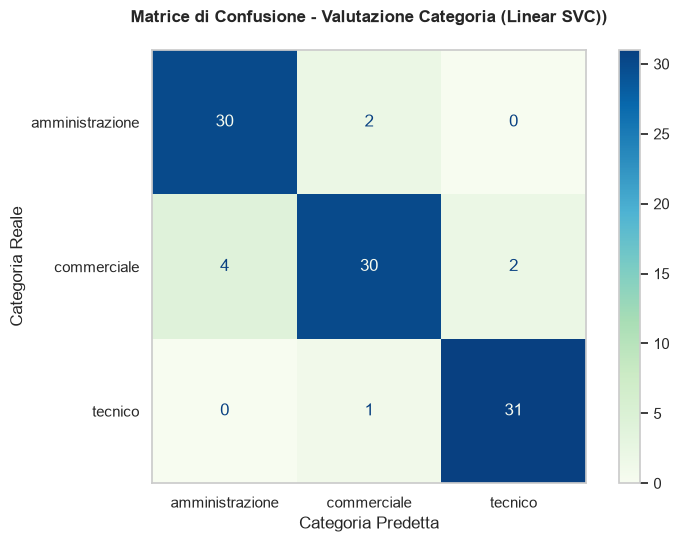

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.patheffects as path_effects

#matrice di confusione
cm = confusion_matrix(y_test, y_pred, labels=modello_categoria.classes_)

#visualizzazione grafica
fig, ax = plt.subplots(figsize=(8, 6),)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modello_categoria.classes_)

disp.plot(cmap='GnBu', ax=ax, values_format='d')

#titoli formali
ax.set_title('Matrice di Confusione - Valutazione Categoria (Linear SVC))', fontsize=12, pad=20,fontweight='bold')
ax.grid(False)
ax.set_xlabel('Categoria Predetta', fontsize=12)
ax.set_ylabel('Categoria Reale', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Algoritmo di classificazione Random Forest

Citando il sito [SnowFlake](https://www.snowflake.com/it/fundamentals/random-forest/):
- Random forest (foresta casuale) è uno degli algoritmi più potenti e diffusi utilizzati nella creazione di modelli di machine learning.
- Questo modello di apprendimento supervisionato costruisce numerosi alberi decisionali e combina le loro previsioni per produrre risultati più accurati e robusti.

--- CLASSIFICATION REPORT - VALUTAZIONE CATEGORIA (Random Forest Classifier) ---
Accuracy Totale: 0.9000

                 precision    recall  f1-score   support

amministrazione       0.85      0.91      0.88        32
    commerciale       0.91      0.83      0.87        36
        tecnico       0.94      0.97      0.95        32

       accuracy                           0.90       100
      macro avg       0.90      0.90      0.90       100
   weighted avg       0.90      0.90      0.90       100



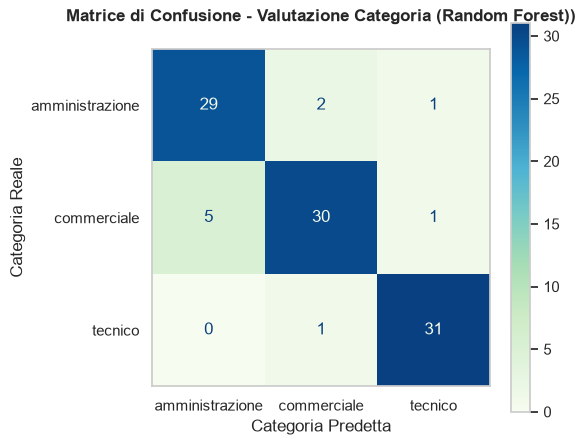

In [ ]:
from sklearn.ensemble import RandomForestClassifier
labels_ordine = ['amministrazione', 'commerciale', 'tecnico']
print("--- CLASSIFICATION REPORT - VALUTAZIONE CATEGORIA (Random Forest Classifier) ---")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)
print(f"Accuracy Totale: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf))
# Matrice di Confusione - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels_ordine)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=labels_ordine)
fig, ax = plt.subplots(figsize=(6, 5))
disp_rf.plot(cmap='GnBu', ax=ax, values_format='d')
ax.set_title('Matrice di Confusione - Valutazione Categoria (Random Forest))', fontsize=12, pad=20,fontweight='bold')
ax.set_xlabel('Categoria Predetta', fontsize=12)
ax.set_ylabel('Categoria Reale', fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

# Fase 4: Modello classificazione priorità

Il problema da affrontare in questa fase è la creazione di codice per un modello che riesca a classificare la priorità di un ticket. 

Proprio come nella fase precedente, sono stati analizzati diversi algoritmi. A seguire è possibile consultarne l'elaborazione.

## Valutazione priorità con Linear SVC

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

#definisco le Feature (X) e il Target (y) => non uso df['token'] perché TF-IDF effettua naturalmente una tokenizzazione
X = df['ticket_completo']
y = df['priority']

#suddivisione in Train Set (80%) e Test Set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

#estrazione delle Feature con TF-IDF
vectorizer_priorità = TfidfVectorizer(
    sublinear_tf=True, 
    min_df=5, 
    ngram_range=(1, 2), 
    stop_words=None #inserendo le stopword italiane con nltk il risultato peggiora
)

#calcola il TF-IDF sui dati di Train e lo applichiamo al Test
X_train_tfidf = vectorizer_priorità.fit_transform(X_train)
X_test_tfidf = vectorizer_priorità.transform(X_test)

#addestramento del Modello (LinearSVC)
modello_priorità = LinearSVC(random_state=42, dual=False)
modello_priorità.fit(X_train_tfidf, y_train)

#predizione e Valutazione Base
y_pred = modello_priorità.predict(X_test_tfidf)

print("--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Linear SVC) ---")
print(f"Accuracy Totale: {accuracy_score(y_test, y_pred):.4f}\n")
print("Report di Classificazione (comprende F1-Macro):")
print(classification_report(y_test, y_pred))

--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Linear SVC) ---
Accuracy Totale: 0.7500

Report di Classificazione (comprende F1-Macro):
              precision    recall  f1-score   support

        alta       0.81      0.88      0.84        33
       bassa       0.67      0.83      0.74        35
       media       0.81      0.53      0.64        32

    accuracy                           0.75       100
   macro avg       0.76      0.75      0.74       100
weighted avg       0.76      0.75      0.74       100



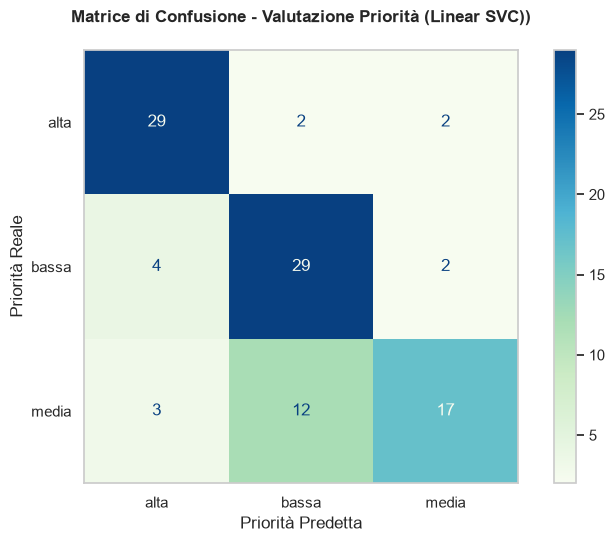

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#matrice di confusione
cm = confusion_matrix(y_test, y_pred, labels=modello_priorità.classes_)

#visualizzazione grafica
fig, ax = plt.subplots(figsize=(8, 6),)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modello_priorità.classes_)

disp.plot(cmap='GnBu', ax=ax, values_format='d')

#titoli formali
ax.set_title('Matrice di Confusione - Valutazione Priorità (Linear SVC))', fontsize=12, pad=20,fontweight='bold')
ax.grid(False)
ax.set_xlabel('Priorità Predetta', fontsize=12)
ax.set_ylabel('Priorità Reale', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Valutazione priorità con Random Forest

--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Random Forest Classifier) ---
Accuracy Totale: 0.7400

              precision    recall  f1-score   support

        alta       0.82      0.97      0.89        33
       bassa       0.69      0.77      0.73        35
       media       0.68      0.47      0.56        32

    accuracy                           0.74       100
   macro avg       0.73      0.74      0.72       100
weighted avg       0.73      0.74      0.73       100



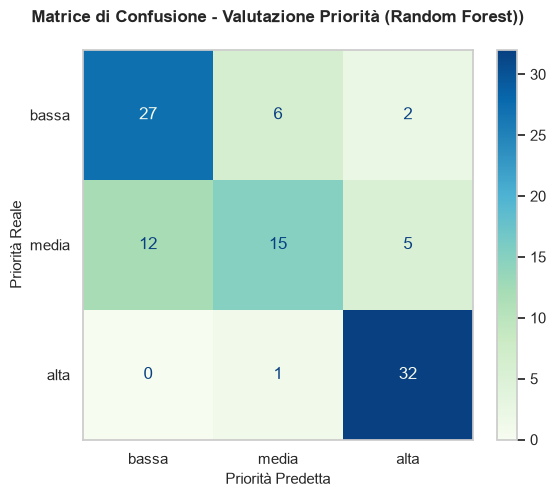

In [ ]:
from sklearn.ensemble import RandomForestClassifier
labels_ordine = ['bassa', 'media', 'alta']
print("--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Random Forest Classifier) ---")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)
print(f"Accuracy Totale: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf))
# Matrice di Confusione - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels_ordine)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=labels_ordine)
fig, ax = plt.subplots(figsize=(6, 5))
disp_rf.plot(cmap='GnBu', ax=ax, values_format='d')
ax.set_title('Matrice di Confusione - Valutazione Priorità (Random Forest))', fontsize=12, pad=20,fontweight='bold')
ax.set_xlabel('Priorità Predetta', fontsize=11)
ax.set_ylabel('Priorità Reale', fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.show()

## Valutazione categoria con approccio gerarchico usando Linear SVC

Un altro approccio è stato quello di un addestramento gerarchico. Questa logica consiste nel addestrare inizialmente il modello nella classificazione delle Categorie e poi addestrarre in maniera verticale dei modelli di priorità per ogni reparto. 

Questo approccio ha aiutato i dataset in difficoltà a spiccare un pò di più sugli altri, e può risultare potenzialmente molto più prestante in dataset di dimensioni maggiori. Avendo a disposizione solo 500 ticket divisi in maniera equa (mediamente 166 ticket per tipo), il problema principale di questa tecnica era proprio il fatto che si creassero dei sotto-dataset troppo piccoli. Riporto comunque la logica utilizzata in quanto ho trovato l'approccio potenzialmente utilizzabile in un potenziale miglioramento del progetto.

Fase 1 (Isolata): Addestramento locale del modello di classificazione delle Categorie...
Fase 2: Addestramento dei modelli di priorità verticali per ogni reparto...
Fase 3: Esecuzione della pipeline sul Test Set...

--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Approccio gerarchico) ---
Accuracy Complessiva sulla Priorità: 0.7000

              precision    recall  f1-score   support

        Alta       0.76      0.88      0.82        33
       Bassa       0.66      0.77      0.71        35
       Media       0.67      0.44      0.53        32

    accuracy                           0.70       100
   macro avg       0.70      0.70      0.69       100
weighted avg       0.70      0.70      0.69       100



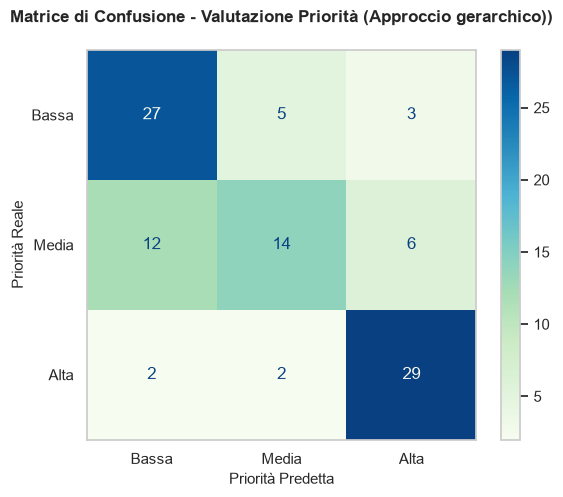

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#recupero dei dati
train_df = df.loc[X_train.index].copy()
test_df = df.loc[X_test.index].copy()

train_df['testo_completo'] = train_df['title'].fillna('') + " " + train_df['body'].fillna('')
test_df['testo_completo'] = test_df['title'].fillna('') + " " + test_df['body'].fillna('')

#modello per la categorie
print("Fase 1 (Isolata): Addestramento locale del modello di classificazione delle Categorie...")

vec_cat_gerarchico = TfidfVectorizer(sublinear_tf=True, min_df=5, ngram_range=(1, 2), stop_words=None)
X_train_cat_gerarchico = vec_cat_gerarchico.fit_transform(train_df['testo_completo'])
X_test_cat_gerarchico = vec_cat_gerarchico.transform(test_df['testo_completo'])

mod_cat_gerarchico = LinearSVC(random_state=42, dual=False)
mod_cat_gerarchico.fit(X_train_cat_gerarchico, train_df['category'])

#predizione delle categorie (Tecnico, Amministrazione, Commerciale)
test_df['pred_category'] = mod_cat_gerarchico.predict(X_test_cat_gerarchico)

#addestramento modelli di priorità per la categoria
print("Fase 2: Addestramento dei modelli di priorità verticali per ogni reparto...")
elenco_categorie = train_df['category'].unique()

modelli_priorita_reparto = {}
vectorizers_priorita_reparto = {}

for cat in elenco_categorie:
    #filtra i dati del TRAIN SET per la categoria corrente
    train_sottogruppo = train_df[train_df['category'] == cat]
    
    vec_prio = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2))
    X_train_prio_sub = vec_prio.fit_transform(train_sottogruppo['testo_completo'])
    
    clf_prio_sub = LinearSVC(random_state=42, dual=False, class_weight='balanced')
    clf_prio_sub.fit(X_train_prio_sub, train_sottogruppo['priority'])
    
    modelli_priorita_reparto[cat.lower().strip()] = clf_prio_sub
    vectorizers_priorita_reparto[cat.lower().strip()] = vec_prio

#pipeline gerarchico del test set
print("Fase 3: Esecuzione della pipeline sul Test Set...")
priorita_predette_finali = []

for idx, riga in test_df.iterrows():
    categoria_stimata = str(riga['pred_category']).lower().strip()
    testo_ticket = riga['testo_completo']
    
    if categoria_stimata in vectorizers_priorita_reparto:
        vettorizzatore_specifico = vectorizers_priorita_reparto[categoria_stimata]
        modello_specifico = modelli_priorita_reparto[categoria_stimata]
        
        testo_vettorizzato = vettorizzatore_specifico.transform([testo_ticket])
        prio_stimata = modello_specifico.predict(testo_vettorizzato)[0]
    else:
        prio_stimata = riga['priority'] 
        
    priorita_predette_finali.append(prio_stimata)

test_df['pred_priority'] = priorita_predette_finali

#valutazione dell'approccio gerarchico
print("\n" + "="*60)
print("--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Approccio gerarchico) ---")
print("="*60)

# Garantiamo la corrispondenza esatta delle stringhe per evitare il ValueError nella matrice
test_df['priority'] = test_df['priority'].str.strip().str.capitalize()
test_df['pred_priority'] = test_df['pred_priority'].str.strip().str.capitalize()

acc_prio = accuracy_score(test_df['priority'], test_df['pred_priority'])
print(f"Accuracy Complessiva sulla Priorità: {acc_prio:.4f}\n")
print(classification_report(test_df['priority'], test_df['pred_priority']))

# Matrice di Confusione protetta
labels_ordine = ['Bassa', 'Media', 'Alta']
cm = confusion_matrix(test_df['priority'], test_df['pred_priority'], labels=labels_ordine)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_ordine)
disp.plot(cmap='GnBu', ax=ax, values_format='d')
plt.title('Matrice di Confusione - Valutazione Priorità (Approccio gerarchico))', fontsize=12, pad=20,fontweight='bold')
ax.set_xlabel('Priorità Predetta', fontsize=11)
ax.set_ylabel('Priorità Reale', fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.show()

# Fase 5: Esportazione dei Modelli

In [ ]:
import joblib

# Salviamo i componenti chiave del sistema
joblib.dump(modello_categoria, 'modelli/m_categoria.pkl')
joblib.dump(vectorizer_categoria, 'modelli/v_categoria.pkl')

# Salviamo anche i dizionari dei modelli verticali delle priorità
joblib.dump(modello_priorità, 'modelli/m_priorità.pkl')
joblib.dump(vectorizer_priorità, 'modelli/v_priorità.pkl')

print("Tutti i modelli e i vettorizzatori sono stati serializzati con successo!")

Tutti i modelli e i vettorizzatori sono stati serializzati con successo!


# Fase 6: Valutazione generale dei vari modelli nei dataset analizzati e possibili miglioramenti

In questa ultima fase analizzerò i risultati ricevuti eseguendo la pipeline presente in questo Notebook nei vari dataset.

Come prima cosa, una breve descrizione dei dataset analizzati:
- **pseudorandom**: Il dataset creato seguendo la pipeline del primo notebook. La sua realizzazione avviene grazie ad un algoritmo che estrae in maniera pseudocasuale verbi e parole chiave per ogni argomento e categoria al fine di realizzare dei ticket immaginari. Per sua struttura, presenta meno ticket con priorità alta per simulare lo sbilanciamento di richieste che si creerebbe nella vita reale;
- **gemma4_unbalanced**: Il primo dei dataset realizzati con Gemma4, dove ho creato dei ticket realizzando in un ciclo la generazione di prompt ad hoc (procedura analizzata nel dettaglio nel secondo notebook). Proprio come il dataset pseudorandom, questo presenta uno sbilanciamento di ticket a priorità alta;
- **gemma4_balanced**: Il secondo dataset realizzato con Gemma4. Questa volta, la quantità di ticket a priorità alta, media o bassa è bilanciata e completamente casuale;
- **gemma4e2b**: Dataset realizzato con Gemma4:e2b, una versione più leggera di Gemma4 con molti parametri in meno, cosa che ha permesso di creare dei ticket meno complessi.
- **unione_di_tutti**: Come dice il nome, in questo dataset ho unito e mischiato tutti i ticket presenti nei dataset precedenti, così da formare un dataset contenente 2000 ticket.

Nella tabella a seguire è possibile consultare una piccola tabella che riassume i migliori valori di accuracy per categoria e priorità ricavati, insieme all'algoritmo che ha realizzato il risultato.

| Dataset | Accuracy Categoria | Accuracy Priorità | Note
| :--- | :---: | :---: | :---: | 
| pseudorandom | 0.91 con LinearSVC | 0.88 RandomForest | Numeri alti sovrastimati dalla pseudocasualità, generalizzando male sui ticket veri (overfitting) |
| gemma4_unbalanced | 0.73 con LinearSVC | 0.54 con Approccio Gerarchico | Risultati pessimi dovuti dallo sbilanciamento del numero di ticket per gruppo di priorità e dalla complessità di Gemma4|
| gemma4_balanced | 0.82 con LinearSVC | 0.53 con Approccio Gerarchico | Anche qui, risultati pessimi dovuti dalla complessità di Gemma4.  |
| gemma4e2b | 0.91 con LinearSVC | 0.75 con LinearSVC | Molto solido e bilanciato, il più robusto |
| unione_di_tutti | 0.93 con Random Forest | 0.80 con LinearSVC | È il vincitore morale. Ha l'accuratezza più alta sulla Categoria e un ottimo 0.80 sulla Priorità, ma è un dataset che contiene tutti i ticket insieme(2000 ticket), quindi da non considerare perché esce fuori dalle specifiche richieste del PW |

Nonostante il modello addestrato con il dataset pseudorandom mostri valori più alti, lo considero meno indicato in quanto allenato su dati più semplici e ripetitivi.

Dunque, il risultato più stabile lo da sicuramente l'algoritmo LinearSVC con il dataset gemma4e2b. Questo risultato lo si deve soprattutto grazie alla funzione *remove_key_word* che ha rimosso una pesante instabilità nel risultato finale per quanto riguarda l'accuracy della categoria (0.98), cosa che dimostrava un grosso problema di overfitting a causa della presenza di parole chiavi come "amministrazione", "tecnico", ecc...

Per questo motivo, saranno il modello e il vettorizzatore generati da gemma4e2b a essere utilizzati per la creazione dell'ultimo punto del PW : una dashboard con output categoria prevista, priorità suggerita e 5 parole più influenti. Sarà possibile vedere il codice nel quarto e ultimo notebook.

Il codice a seguire permette un analisi delle parole più influenti per ogni classe (ovvero le 10 parole con il coefficiente positivo più alto per le varie categorie e le varie priorità).

## Top 10 parole più influenti per la categoria:

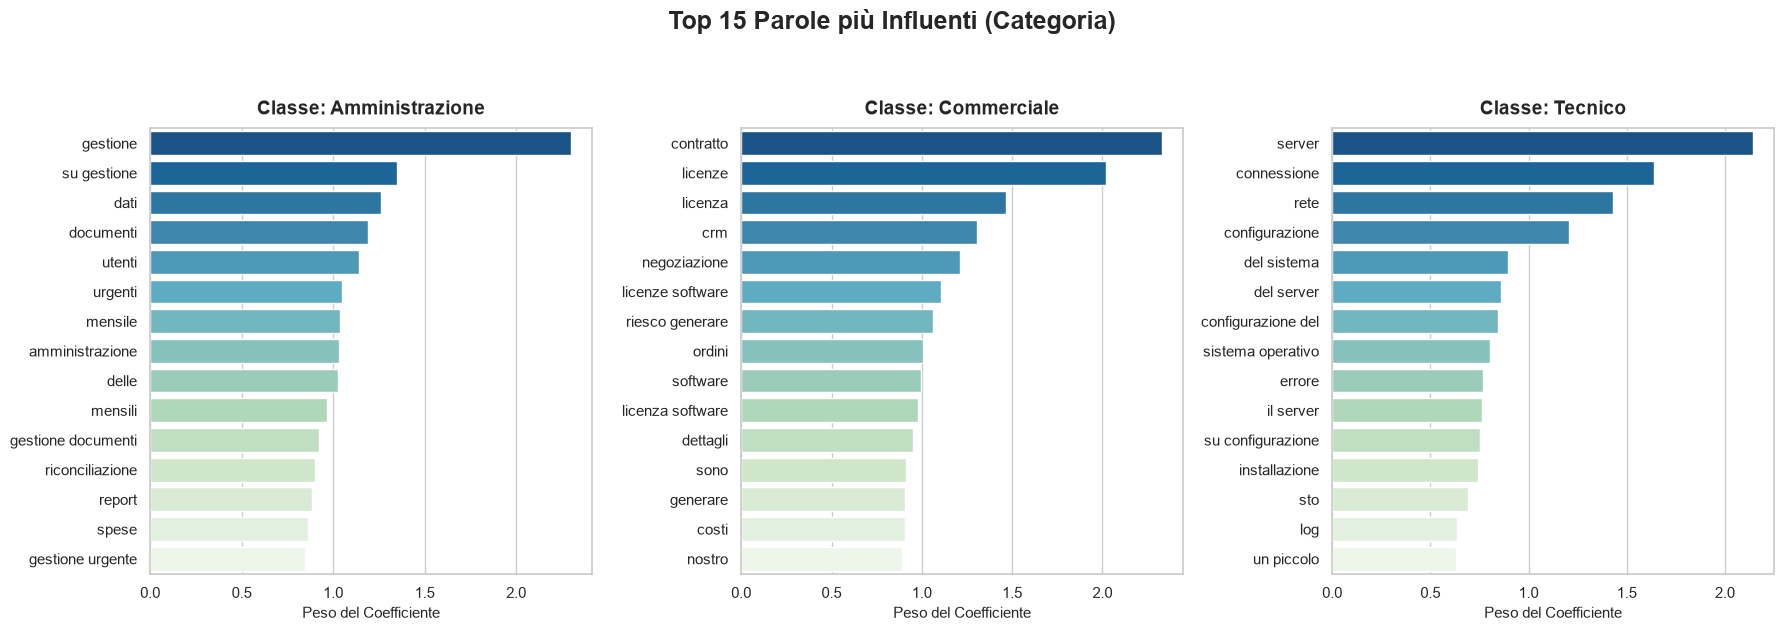

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

#recupera le feature e i coefficienti dal modello
feature_names = np.array(vectorizer_categoria.get_feature_names_out())
coefficients = modello_categoria.coef_
class_labels = modello_categoria.classes_

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False)
fig.suptitle('Top 15 Parole più Influenti (Categoria)', fontsize=18, fontweight='bold', y=1.05)

palette = sns.color_palette("GnBu_r", 15)

for i, class_label in enumerate(class_labels):
    #trova i primi 15 indici con coefficiente positivo più alto
    top_indices = np.argsort(coefficients[i])[::-1][:15]
    
    top_words = feature_names[top_indices]
    top_coefs = coefficients[i][top_indices]
    
    df_temp = pd.DataFrame({
        'Parola': top_words,
        'Coefficiente': top_coefs
    })
    
    #disegna il grafico a barre orizzontali sul sotto-grafico corrente
    sns.barplot(
        data=df_temp,
        x='Coefficiente',
        y='Parola',
        ax=axes[i],
        palette=palette,
        hue='Parola',
        legend=False
    )
    
    axes[i].set_title(f"Classe: {class_label.capitalize()}", fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel("Peso del Coefficiente", fontsize=11)
    axes[i].set_ylabel("", fontsize=11)
    axes[i].tick_params(axis='y', labelsize=11) #singoli token

plt.tight_layout()
plt.show()

## Top 10 parole più influenti per la priorità

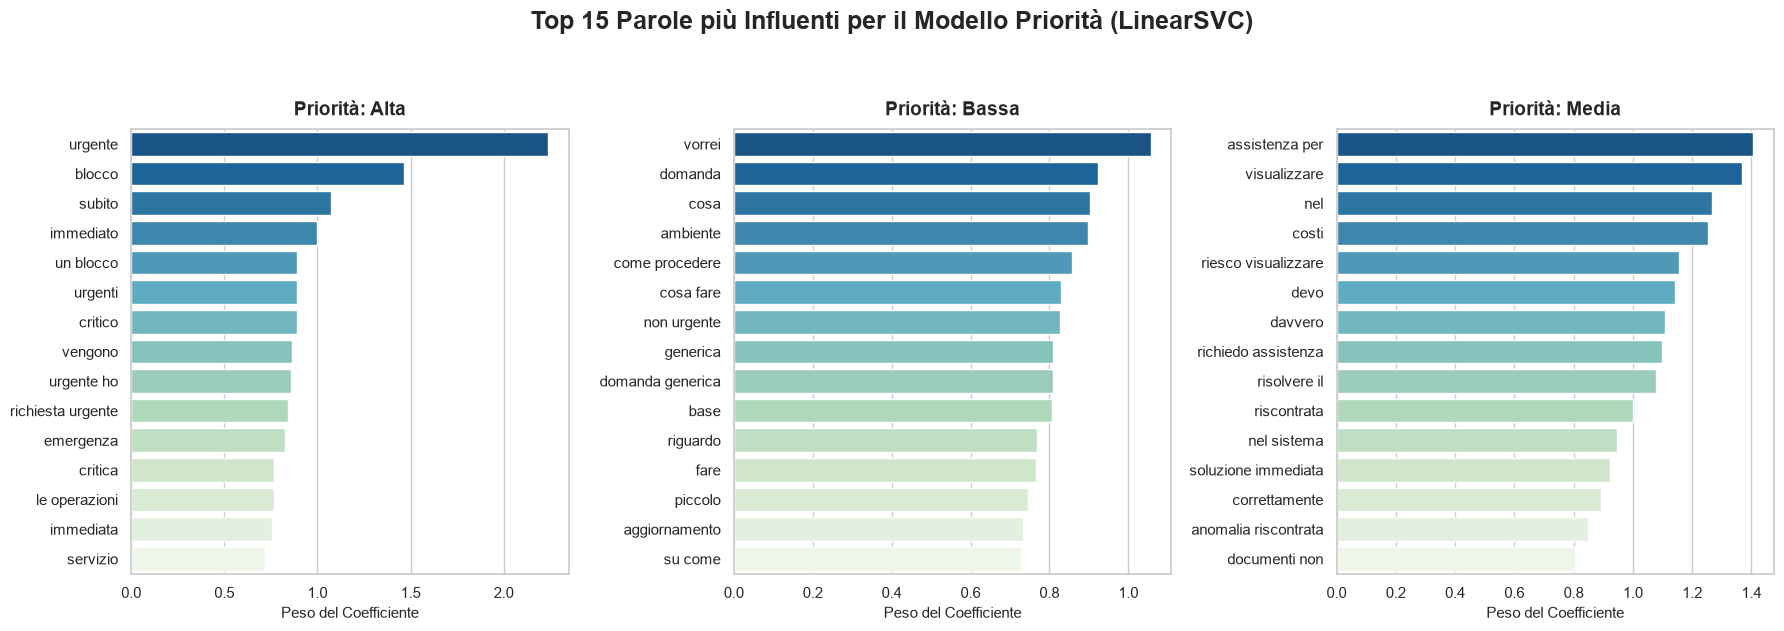

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

feature_names = np.array(vectorizer_priorità.get_feature_names_out())

coefficients = modello_priorità.coef_
class_labels = modello_priorità.classes_


num_classi = len(class_labels)

fig, axes = plt.subplots(1, num_classi, figsize=(6 * num_classi, 6), sharex=False)
fig.suptitle('Top 15 Parole più Influenti per il Modello Priorità (LinearSVC)', fontsize=18, fontweight='bold', y=1.05)

palette = sns.color_palette("GnBu_r", 15)

for i, class_label in enumerate(class_labels):
    top_indices = np.argsort(coefficients[i])[::-1][:15]
    
    top_words = feature_names[top_indices]
    top_coefs = coefficients[i][top_indices]
    
    df_temp = pd.DataFrame({
        'Parola': top_words,
        'Coefficiente': top_coefs
    })
    
    sns.barplot(
        data=df_temp,
        x='Coefficiente',
        y='Parola',
        ax=axes[i],
        palette=palette,
        hue='Parola',       
        legend=False
    )
    
    axes[i].set_title(f"Priorità: {class_label.capitalize()}", fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel("Peso del Coefficiente", fontsize=11)
    axes[i].set_ylabel("", fontsize=11)
    axes[i].tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.show()

## Possibili futuri miglioramenti

Da quest'ultima analisi (feature più rilevanti per entrambi i modello), emerge la presenza di token semanticamente sovrapponibili ma morfologicamente distinti, come i singolari e plurali dei termini chiave (es. 'problema' / 'problemi' o 'urgente' / 'urgenti').

Questo fenomeno è facilmente risolvibile come potenziale futuro miglioramento grazie ad un operazione di **lemmatizzazione** (riduzione alla forma canonica o lemma) o di Stemming (estrazione della radice fissa della parola) all'interno della pipeline di preprocessing. 

Altre potenziali modifiche future potrebbero essere modifiche dei parametri chiave utilizzati. Nella pipeline attuale, i parametri utilizzati sono abbastanza generici e standard, ma potrebbero essere modificati per massimizzare la generalizzazione, ad esempio:

- Random Forest: Esplorazione della profondità massima (max_depth) per prevenire l'overfitting sui testi di training, e l'ottimizzazione del numero minimo di campioni per foglia (min_samples_leaf) per migliorare le regole decisionali.

- LinearSVC: Variazione del parametro di regolarizzazione (C). Un valore di C ottimizzato potrebbe permettere di trovare il giusto compromesso tra un margine di separazione ampio (che generalizza meglio) e la corretta classificazione dei ticket più ambigui nel training set.

Un altro potenziale sviluppo futuro per questo progetto consiste nel superamento dell'approccio TF-IDF attraverso l'utilizzo di **BERT** (Bidirectional Encoder Representations from Transformers), un modello di Deep Learning sviluppato da Google e basato sull'architettura Transformer ([link per approfondimento](https://www.snowflake.com/it/fundamentals/bert/)).

A differenza del modello creato in questa pipeline, BERT è pre-addestrato su enormi quantità di testo e analizza le frasi in modo bidirezionale (leggendo contemporaneamente il contesto a destra e a sinistra di ogni parola). L'integrazione di questa architettura garantirebbe due netti miglioramenti:

- Risoluzione delle ambiguità (Polisemia): BERT è in grado di comprendere il significato del termine in base al contesto in cui si trova. Es: distinguerebbe la frase 'reset del router' (ticket Tecnico) dalla frase 'reset del contratto' (ticket Commerciale).

- Comprensione semantica profonda: Per sua natura questo modello riesce a riconoscere sinonimi o termini affini (es: 'urgente', 'critico', 'immediato', ecc...). Questo permetterebbe di incrementare non di poco la precisione sulla classificazione delle priorità, che è l'area in cui il TF-IDF ha mostrato i margini di miglioramento più ampi.